# Simple-Salesforce

This notebook demonstrates how to make an API connection into a Salesforce platform. Interacting with a Salesforce instance via API allows you to perform real-time analysis from a single source of truth and write advanced automations. 

Some benefits to this approach (as opposed to a data replication/warehousing approach) include:
- Reduced infrastructure complexity and storage costs
- Reduced governance risk / simplified compliance posture (not a new system or platform to maintain/document)
- Leverages the Salesforce security model (object/field level permissions, sharing, roles, and permissions)
- Access to Salesforce specific features (e.g. APEX, SOQL, formula fields, roll-ups, events, metadata)
- Faster initial development / pilots (can develop features without modifying system-level objects and fields)
- No drift in the data scheme from the source system

If you need to combine data across multiple systems or run analysis on historical data that may involve millions of records, the extra development and cost required to configure a robust data warehouse is likely necessary. It all depends on what you're trying to accomplish/process.

If you're [Elon Tusk](https://youtu.be/4xIwP-65oD0?si=sjjQTtliCmqK0Vn3), your hardware doesn't even exist yet:

<img
    src='https://media.licdn.com/dms/image/v2/D5622AQHduqJi_RR5Pg/feedshare-shrink_800/B56ZxJ48PPH0Ag-/0/1770766189738?e=2147483647&v=beta&t=mYPBsLlrnTwuI2XZWCYqGHifDX3qlj_FY39hFz1G86o'
    width='200px'
/>

If you're a normal person, the setup below can achieve more than you ever thought was possible (Shiba for scale):

<img
    src='memes/neeshie.jpeg'
    width='200px'
/>

## Utility File

Configuration and code complexity is abstracted into a utility file that maximizes code reuse and readability. Notebooks interface with this utility so that you do not need to ever re-create the wheel:

In [1]:
import apis.sfdc as util

To use the API, you will first need to have access to a Salesforce platform with [a Connected App](https://help.salesforce.com/s/articleView?id=xcloud.connected_app_overview.htm&type=5) and an API-enabled user. You can sign up for a free [Salesforce Developer Edition instance](https://www.salesforce.com/products/free-trial/developer/) if you do not have a current Salesforce logn. 

In your instance, create a connected app with Client Credentials Flow active and "Run As" set to an API-enabled user. Copy the consumer key, secret, and your unique salesforce domain into environment variables before calling the connection class:

In [2]:
sfdc = util.SalesforceConnection()

# Running Queries

Perhaps the most useful capability of the API is the ability to query and structure data that is stored within Salesforce records. Specific objects, and their related objects, can be queried and filtered using *Salesforce Object Query Language* (SOQL) statements.

In [3]:
accounts = sfdc.query(
    """
    SELECT Name, Industry, AnnualRevenue, Phone, Website,
        (SELECT Amount FROM Opportunities WHERE StageName = 'Closed Won'),
        (SELECT Id FROM Cases)
    FROM Account
    """
)
accounts

,Name,Industry,AnnualRevenue,Phone,Website,ClosedWonAmount,CaseCount
0,Edge Communications,Electronics,1.390000e+08,(512) 757-6000,http://edgecomm.com,185000.0,3
1,Burlington Textiles Corp of America,Apparel,3.500000e+08,(336) 222-7000,www.burlington.com,235000.0,2
2,Pyramid Construction Inc.,Construction,9.500000e+08,(014) 427-4427,www.pyramid.com,0.0,0
3,Dickenson plc,Consulting,5.000000e+07,(785) 241-6200,dickenson-consulting.com,0.0,0
4,Grand Hotels & Resorts Ltd,Hospitality,5.000000e+08,(312) 596-1000,www.grandhotels.com,650000.0,4
5,United Oil & Gas Corp.,Energy,5.600000e+09,(212) 842-5500,http://www.uos.com,2100000.0,7
6,Express Logistics and Transport,Transportation,9.500000e+08,(503) 421-7800,www.expressl&t.net,220000.0,3
7,University of Arizona,Education,NaN,(520) 773-9050,www.universityofarizona.com,140000.0,1
8,"United Oil & Gas, UK",Energy,NaN,+44 191 4956203,http://www.uos.com,0.0,1
9,"United Oil & Gas, Singapore",Energy,NaN,(650) 450-8810,http://www.uos.com,0.0,3


<img
    src='memes/sql.png'
    width='300px'
/>  

## Analyzing a Query

With a bit of creativity and determination, queried data can be analyzed using python libraries such as matplotlib... Remember, the quality of your analysis is always going to be dependent on the quality of data stored within your Salesforce platform. 

The plots below call custom functions written in the utility file. The first plot calculates the average annual revenue for each account industry that is stored in the instance (annual revenue refers to the account's annual revenue):

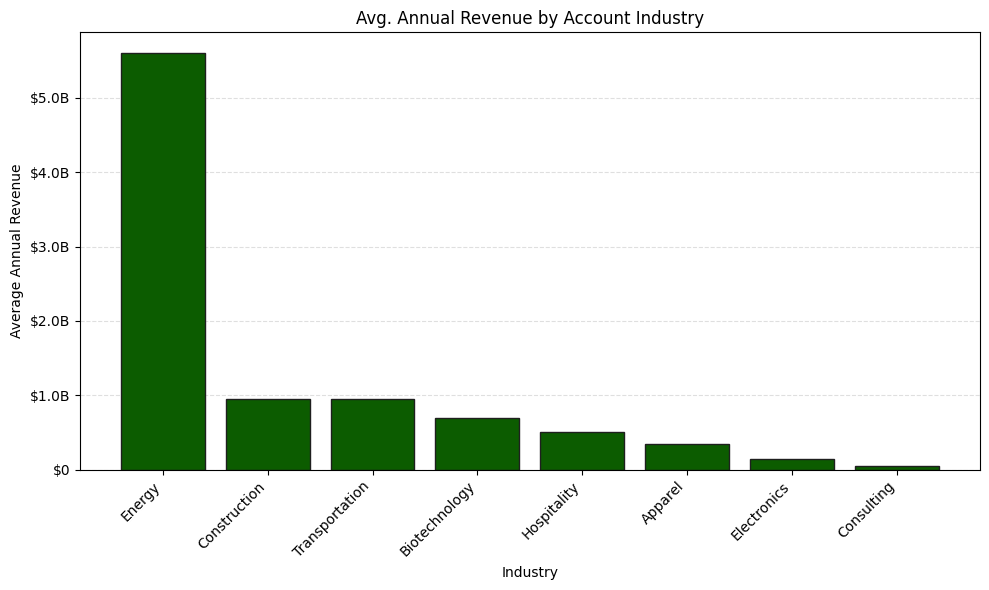

In [4]:
util.plot_avg_revenue_by_industry(accounts)

The plot below uses a function that allows an analyst to see up to the top accounts within a specific industry based on the value of related opportunities that are designated as "Closed Won" inside of Salesforce:

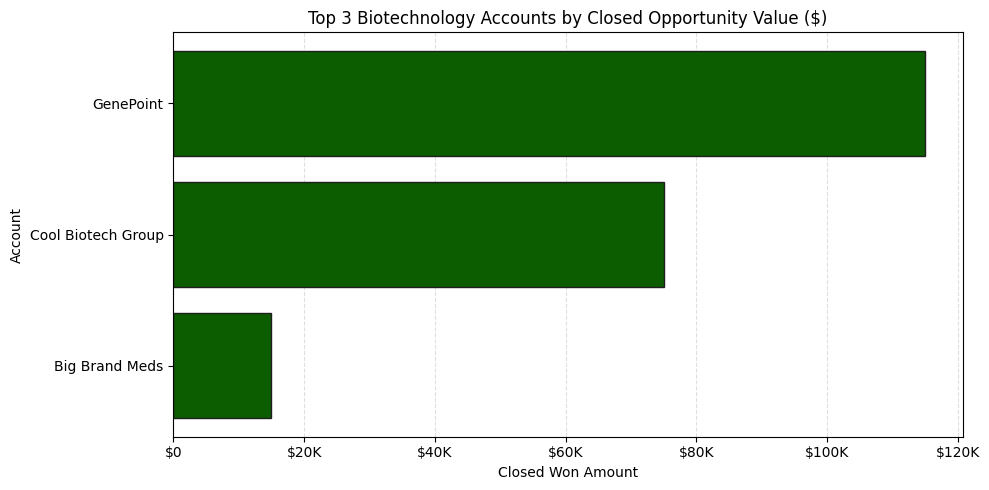

In [5]:
util.plot_top_closed_won(accounts, 'Biotechnology')

*Since there are only 3 total biotech accounts in the salesforce platform, all are shown in the plot*

# Data Manipulation Language (DML) Operations 

Salesforce DML (Data Manipulation Language) statements are used to directly manage records within the Salesforce platform. These operations enable applications to create, modify, restore, and remove data. The core DML statements include insert, update, upsert, delete, undelete, and merge.

The examples below demonstrate how the Salesforce API can be used to create new Account records, update existing Accounts, and delete Accounts.

<img
    src='memes/shiba_humor.jpg'
    width='250px'
/>  

In real-world applications, DML operations are often executed in response to external events, such as processing data submitted through a web form, integrating with third-party systems, or handling automated business workflows in real time.

In [6]:
# define a payload with structured new account information to create in Salesforce.
new_accounts = [
    {
        'Name': 'ML Cookbook Demo 1', 
        'Industry': 'Consulting', 
        'Type': 'Prospect'
    },
    {'Name': 'ML Cookbook Demo 2', 'Industry': 'Consulting', 'Type': 'Prospect'},
    {'Name': 'ML Cookbook Demo 3', 'Industry': 'Consulting', 'Type': 'Prospect'},
]

In [7]:
# store each new account ID in a list as they are created in Salesforce
new_account_ids = []
for account in new_accounts:
    result = sfdc.Account.create(account)
    new_account_ids.append(result['id'])

In [8]:
# query new accounts based on their IDs using the custom list query
sfdc.query_list(
    'SELECT Id, Name, Type, Industry, Phone FROM Account WHERE Id IN ',
    new_account_ids
)

,Id,Name,Type,Industry
0,001fj00001GiTUXAA3,ML Cookbook Demo 2,Prospect,Consulting
1,001fj00001GjJEaAAN,ML Cookbook Demo 1,Prospect,Consulting
2,001fj00001GjfYMAAZ,ML Cookbook Demo 3,Prospect,Consulting


In [9]:
# update the first account's phone number
sfdc.Account.update(new_account_ids[0], {'Phone': '(555) 010-0001'})
sfdc.query_list(
    'SELECT Id, Name, Industry, Phone FROM Account WHERE Id IN ',
    new_account_ids
)

,Id,Name,Industry,Phone
0,001fj00001GiTUXAA3,ML Cookbook Demo 2,Consulting,NaN
1,001fj00001GjJEaAAN,ML Cookbook Demo 1,Consulting,(555) 010-0001
2,001fj00001GjfYMAAZ,ML Cookbook Demo 3,Consulting,NaN


In [10]:
# delete the all the new accounts that were created
for i in range(len(new_account_ids)):
    sfdc.Account.delete(new_account_ids[i])

In [11]:
sfdc.query_list(
    'SELECT Id, Name, Industry, Phone FROM Account WHERE Id IN ',
    new_account_ids
)

""
